Entries = 100000
vlm 2 points = 4366
vlm 3 points = 661


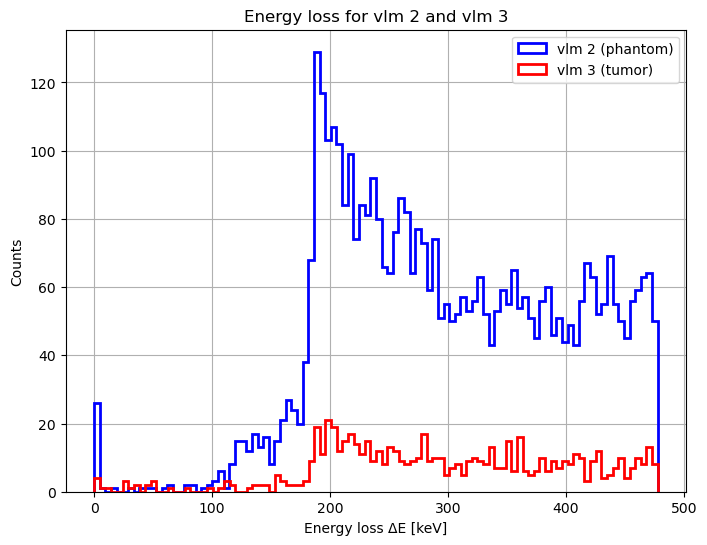

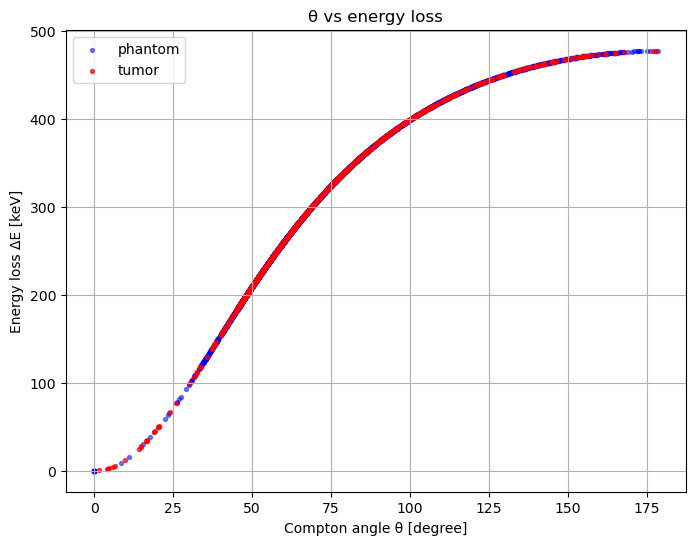

In [3]:
import ROOT
import math
import numpy as np
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
root_file = "tumor.root"
tree_name = "t"

E0 = 662.0   # keV

# =========================
# OPEN ROOT FILE
# =========================
f = ROOT.TFile.Open(root_file)

if not f or f.IsZombie():
    raise RuntimeError("Could not open ROOT file")

t = f.Get(tree_name)

if not t:
    raise RuntimeError("Could not find tree")

print("Entries =", t.GetEntries())

# =========================
# STORAGE
# =========================
eloss_vlm2 = []
eloss_vlm3 = []

# optional theta storage
theta_vlm2 = []
theta_vlm3 = []

me = 511.0

# =========================
# LOOP OVER EVENTS
# =========================
for entry in t:

    n = min(
        len(entry.pdg),
        len(entry.vlm),
        len(entry.et)
    )

    for i in range(n):

        # only gammas
        if int(entry.pdg[i]) != 22:
            continue

        vlm = int(entry.vlm[i])

        # only vlm 2 and 3
        if vlm not in [2, 3]:
            continue

        Es = float(entry.et[i])

        if Es <= 0 or Es >= E0:
            continue

        # energy loss
        dE = E0 - Es

        # Compton angle
        cos_theta = 1.0 - me * (1.0 / Es - 1.0 / E0)

        if cos_theta < -1 or cos_theta > 1:
            continue

        theta = math.degrees(math.acos(cos_theta))

        # =========================
        # STORE BY VOLUME
        # =========================
        if vlm == 2:
            eloss_vlm2.append(dE)
            theta_vlm2.append(theta)

        elif vlm == 3:
            eloss_vlm3.append(dE)
            theta_vlm3.append(theta)

# =========================
# CONVERT TO NUMPY
# =========================
eloss_vlm2 = np.array(eloss_vlm2)
eloss_vlm3 = np.array(eloss_vlm3)

theta_vlm2 = np.array(theta_vlm2)
theta_vlm3 = np.array(theta_vlm3)

print("vlm 2 points =", len(eloss_vlm2))
print("vlm 3 points =", len(eloss_vlm3))

# =========================
# PLOT ENERGY LOSS HISTOGRAM
# =========================
plt.figure(figsize=(8,6))

plt.hist(
    eloss_vlm2,
    bins=100,
    histtype="step",
    linewidth=2,
    color="blue",
    label="vlm 2 (phantom)"
)

plt.hist(
    eloss_vlm3,
    bins=100,
    histtype="step",
    linewidth=2,
    color="red",
    label="vlm 3 (tumor)"
)

plt.xlabel("Energy loss ΔE [keV]")
plt.ylabel("Counts")
plt.title("Energy loss for vlm 2 and vlm 3")

plt.legend()
plt.grid(True)
plt.show()

# =========================
# OPTIONAL:
# THETA vs ENERGY LOSS
# =========================
plt.figure(figsize=(8,6))

plt.scatter(
    theta_vlm2,
    eloss_vlm2,
    s=8,
    alpha=0.5,
    color="blue",
    label="phantom"
)

plt.scatter(
    theta_vlm3,
    eloss_vlm3,
    s=8,
    alpha=0.7,
    color="red",
    label="tumor"
)

plt.xlabel("Compton angle θ [degree]")
plt.ylabel("Energy loss ΔE [keV]")

plt.title("θ vs energy loss")

plt.legend()
plt.grid(True)
plt.show()